In [1]:
#драйвер clickhouse и библиотеки визуализации
!pip install clickhouse-connect matplotlib seaborn pandas -q

#импорт необходимых библиотек
import clickhouse_connect
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
#подключение к кх через сетевой алиас контейнера в докере
client = clickhouse_connect.get_client(
    host='clickhouse', 
    port=8123, 
    username='default', 
    password='clickhouse123', 
    database='game_analytics'
)
print("дальше")

дальше


In [2]:
#получение поминутных агрегированных метрик из Мвьюхи
query_1 = """
SELECT 
    minute,
    events,
    total_score,
    anomalies,
    round(avg_score, 2) AS avg_score
FROM events_agg_1m_readable
ORDER BY minute ASC;
"""

df_ts = client.query_df(query_1)

#вывод первых 10 строк таблицы
df_ts.head(10)

,minute,events,total_score,anomalies,avg_score
0,2026-10-05 09:59:00,1,40,0,37.00
1,2026-10-05 09:59:00,1,42,0,42.00
2,2026-10-05 09:59:00,1,-10,0,9.67
3,2026-10-05 09:59:00,1,160,0,182.40
4,2026-10-05 09:59:00,1,185,0,185.00
5,2026-10-05 09:59:00,2,139,0,60.33
6,2026-10-05 09:59:00,1,8,0,8.00
7,2026-10-05 09:59:00,1,-97,0,-91.25
8,2026-10-05 09:59:00,2,360,0,175.60
9,2026-10-05 09:59:00,1,27,0,27.00


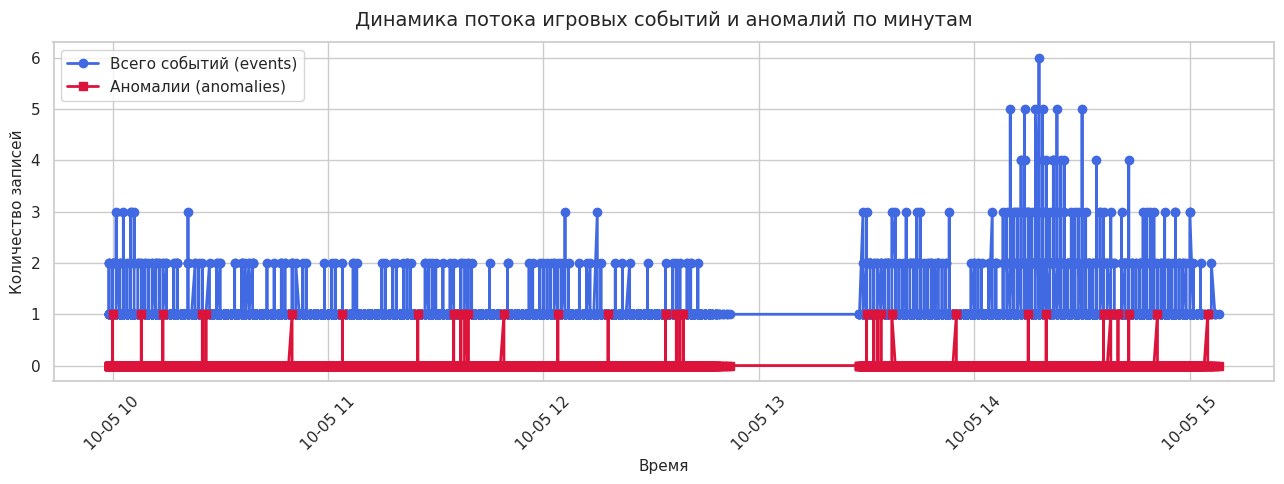

In [3]:
plt.figure(figsize=(13, 5))

#отрисовка линий общего потока игр и аномалий
plt.plot(df_ts['minute'], df_ts['events'], label='Всего событий (events)', color='royalblue', marker='o', linewidth=2)
plt.plot(df_ts['minute'], df_ts['anomalies'], label='Аномалии (anomalies)', color='crimson', marker='s', linewidth=2)

plt.title('Динамика потока игровых событий и аномалий по минутам', fontsize=14, pad=12)
plt.xlabel('Время', fontsize=11)
plt.ylabel('Количество записей', fontsize=11)
plt.xticks(rotation=45)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

In [4]:
#выборка сырых событий для анализа распределения очков
query_2 = """
SELECT 
    event_type,
    game_mode,
    score,
    duration_ms,
    is_anomaly
FROM game_events
LIMIT 20000;
"""

df_events = client.query_df(query_2)

#сравнение очков для аномальных и нормльных событий
df_events.groupby(['event_type', 'is_anomaly'])['score'].describe()

count         mean         std     min     25%  \
event_type is_anomaly                                                    
assist     0           3997.0    52.478359   16.299602     3.0    42.0   
           1             51.0   240.431373   93.236957    77.0   177.0   
boss_kill  0           1105.0   531.818100   67.452321   356.0   489.0   
           1             11.0  2295.727273  429.305740  1906.0  1922.0   
death      0           5652.0   -85.422682   17.906456  -151.0   -98.0   
           1             57.0  -374.508772  126.722718  -779.0  -459.0   
kill       0           4236.0   178.269830   26.890300    91.0   160.0   
           1             40.0   820.500000  168.279377   553.0   697.0   
level_up   0           2777.0    34.222902   15.645259   -15.0    23.0   
           1             37.0   148.918919   53.245437    22.0   112.0   
purchase   0           2024.0     8.624506   14.539642   -35.0    -1.0   
           1             13.0     1.153846   89.737438  -187.0   -34.0   

                          50%     75%     max  
event_type is_anomaly                          
assist     0             52.0    63.0   105.0  
           1            223.0   289.0   530.0  
boss_kill  0            533.0   580.0   688.0  
           1           2077.0  2534.0  3020.0  
death      0            -86.0   -73.0   -26.0  
           1           -355.0  -281.0  -214.0  
kill       0            178.0   198.0   254.0  
           1            817.0   961.0  1102.0  
level_up   0             34.0    45.0    88.0  
           1            135.0   189.0   242.0  
purchase   0              8.0    19.0    50.0  
           1             -5.0    33.0   201.0

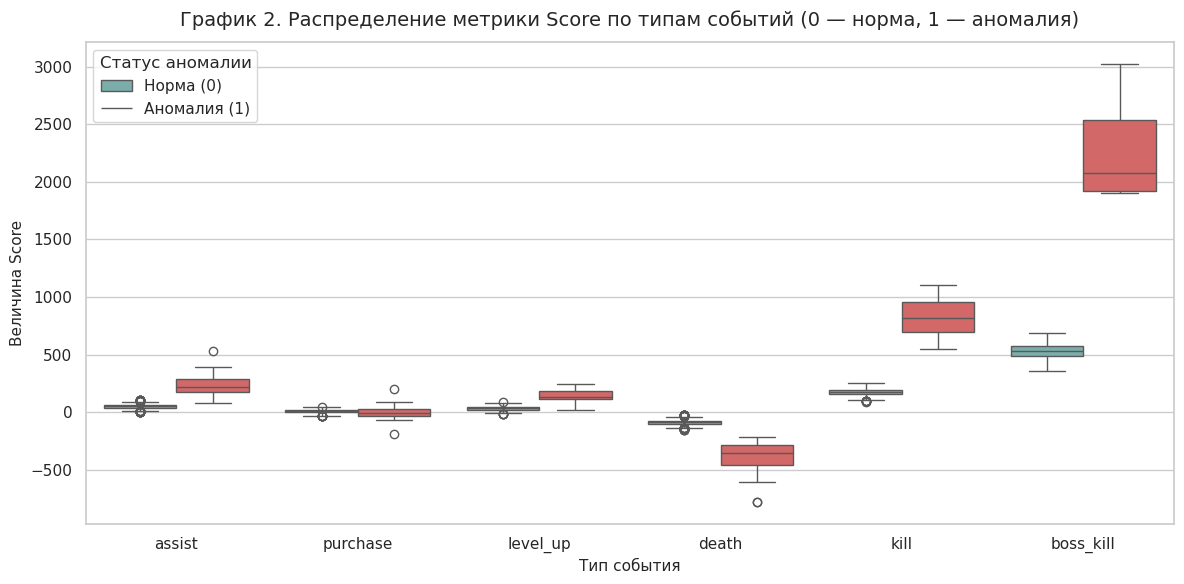

In [5]:
plt.figure(figsize=(12, 6))

#бокс
sns.boxplot(
    data=df_events, 
    x='event_type', 
    y='score', 
    hue='is_anomaly', 
    palette={0: '#72b7b2', 1: '#e45756'}
)

plt.title('Распределение метрики score по типам событий (0 — норма, 1 — аномалия)', fontsize=14, pad=12)
plt.xlabel('Тип события', fontsize=11)
plt.ylabel('Величина score', fontsize=11)
plt.legend(title='Статус аномалии', labels=['Норма (0)', 'Аномалия (1)'])
plt.tight_layout()
plt.show()

In [6]:
#из справочника игроков ищем подозрительных
query_3 = """
SELECT 
    p.player_id,
    p.username,
    p.country,
    p.skill_mmr,
    countIf(e.is_anomaly = 1) AS anomalies_count,
    count() AS total_events,
    round(anomalies_count / total_events * 100, 2) AS anomaly_rate_pct
FROM game_events e
JOIN players p ON e.player_id = p.player_id
GROUP BY p.player_id, p.username, p.country, p.skill_mmr
HAVING anomalies_count > 0
ORDER BY anomalies_count DESC
LIMIT 10;
"""

df_players = client.query_df(query_3)
df_players

,p.player_id,username,country,skill_mmr,anomalies_count,total_events,anomaly_rate_pct
0,3,player_3,BR,1448.964722,104,4160,2.50
1,98,player_98,KR,1153.042358,96,3120,3.08
2,22,player_22,CN,1581.692383,90,3560,2.53
3,12,player_12,US,1853.490601,86,3280,2.62
4,173,player_173,RU,500.000000,78,3520,2.22
5,80,player_80,DE,1570.254761,76,4080,1.86
6,73,player_73,KR,899.585510,70,3400,2.06
7,155,player_155,DE,1285.726440,66,3680,1.79
8,136,player_136,KR,2043.373657,66,4120,1.60
9,27,player_27,JP,1437.565796,66,3880,1.70


### Аналитические выводы:1. **Аномалии**
   
      При значении `is_anomaly = 1` генерируемый `score` умножается на случайный коэффициент от 3 до 6. Это четко подтверждается графиком Boxplot: для действий `kill` и `boss_kill` максимальные значения очков резко превышают 1500–2000 пунктов, что выходит далеко за пределы нормального распределения3

2. **Частота проявления:** 
   Доля аномалий держится на уровне ~1% от всего потока данных. Это свидетельствует о корректной работе генератора потоковых данных и соблюдении заданного порога вероятности генерации выбро4ов.

3. **Бизнес-интерпретация:** 
   Аномальные значения в рейтингplayers`) могут свидетельствовать об использовании чит, анса или бустинга  или смурфингаа Все эти факторы негативно влияют на опыт обычных пользователей, что приводит к угасанию интереса к игре и в следствие потере пользователей и финансов.  Обнаружение таких значений позволяет создавать закономерности для определения такого рода вещей и последующим их пресечением.
   Другие показатели, например, страна и количество игр помогают определить основное географическое положение пользователей с наибольшим интересом к игре. Такой фактор помогает разработчикам учитывать при обновлении игры разные ценности, вкусы игроков. Это позволит создавать контент (скины, карты и другое), который понравится большей части игроков, что принесет больше выгоды.
   Параметры смертей, убийств и т.д. позволяют балансировать способности, местность и другие механики игры для большей честности, что также положительно сказывается на отношении пользователей к игре. дерборда.